## Assignment-17 Time Series

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'Data\exchange_rate.csv')
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [3]:
df.columns

Index(['date', 'Ex_rate'], dtype='object')

In [4]:
# covert date column to datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

In [5]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Convert date properly
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Set index
df.set_index('date', inplace=True)

In [6]:
# view data
print(df.head())

            ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849


##### initial Exploration

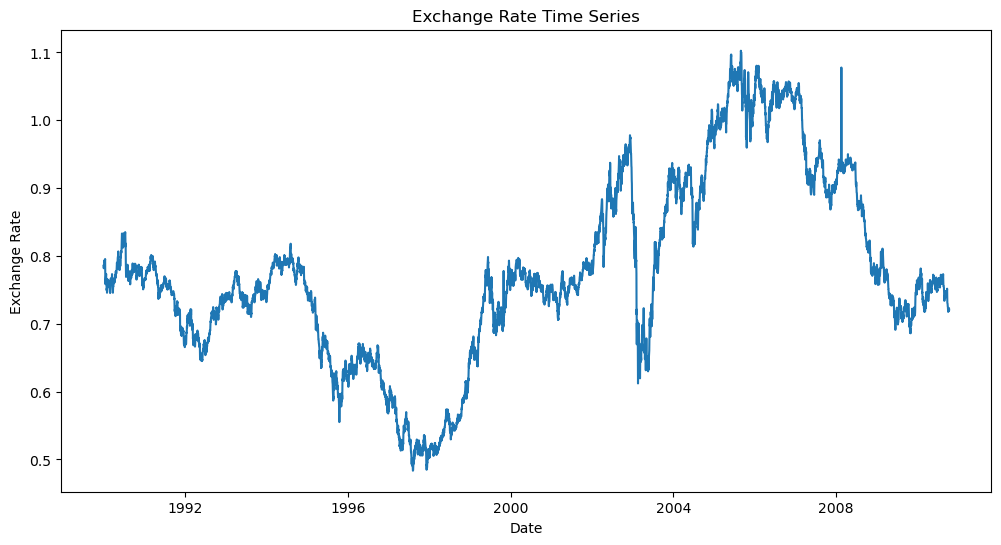

In [8]:
# plot time series
plt.figure(figsize=(12,6))

plt.plot(df.iloc[:,0],
         label='USD to AUD'
        )
plt.title('Exchange Rate Time Series')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')

plt.show()

##### Data Preprocessing

In [18]:
# check missing values 
print(df.isnull().sum())

ex_rate    0
dtype: int64


In [10]:
# Fill missing values 

df.fillna(method='ffill', inplace= True)

C:\Users\javee\AppData\Local\Temp\ipykernel_11404\476222644.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace= True)


#### ARIMA Model

Stationarity Check

In [11]:
from statsmodels.tsa.stattools import adfuller

In [12]:
result = adfuller(df.iloc[:,0])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.6649941807381368
p-value: 0.4492327353597985


If p-value > 0.05, data is non-stationary --> apply differencing

In [13]:
df_diff = df.diff().dropna()

##### ACF & PACF Plots

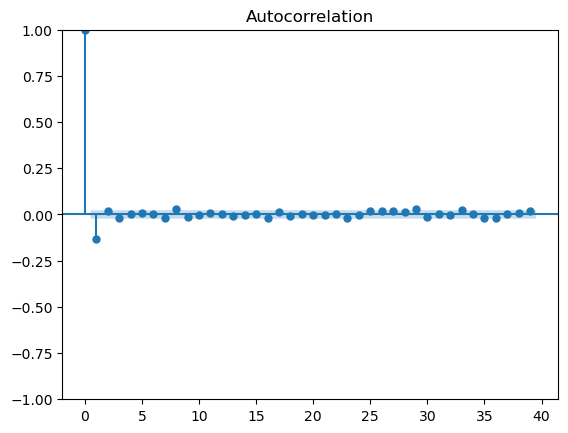

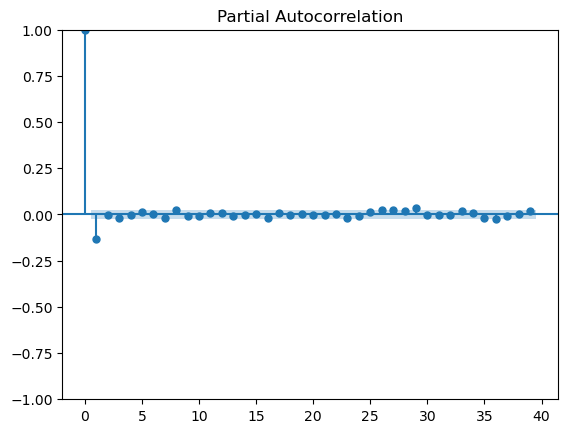

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_diff)
plot_pacf(df_diff)

plt.show()

##### Model Fitting

In [22]:
df.columns

Index(['ex_rate'], dtype='object')

In [15]:
from statsmodels.tsa.arima.model import ARIMA

In [29]:

import warnings

from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# Convert Ex_rate to numeric
df['ex_rate'] = pd.to_numeric(df['ex_rate'], errors='coerce')

# Remove missing values
df.dropna(inplace=True)

# Select series
series = df['ex_rate']

# Train-Test Split
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

# Grid Search
p = range(0, 3)
d = range(0, 2)
q = range(0, 3)

best_aic = np.inf
best_order = None

for i in p:
    for j in d:
        for k in q:

            try:
                model = ARIMA(train, order=(i, j, k))

                result = model.fit()

                print(f"ARIMA({i},{j},{k}) AIC = {result.aic}")

                # Select lowest AIC
                if result.aic < best_aic:

                    best_aic = result.aic
                    best_order = (i, j, k)

            except Exception as e:
                print(e)

print("\nBest ARIMA Order:", best_order)
print("Lowest AIC Value:", best_aic)

ARIMA(0,0,0) AIC = -6939.430309240077
ARIMA(0,0,1) AIC = -14943.418152166305
ARIMA(0,0,2) AIC = -21547.17826400345
ARIMA(0,1,0) AIC = -45406.2551403845
ARIMA(0,1,1) AIC = -45424.939921959114
ARIMA(0,1,2) AIC = -45426.41238756152
ARIMA(1,0,0) AIC = -45405.092886863495
ARIMA(1,0,1) AIC = -45423.43746055455
ARIMA(1,0,2) AIC = -45425.057982875995
ARIMA(1,1,0) AIC = -45425.95672915418
ARIMA(1,1,1) AIC = -45432.09158325904
ARIMA(1,1,2) AIC = -45429.88041939499
ARIMA(2,0,0) AIC = -45424.46442302716
ARIMA(2,0,1) AIC = -45429.70334932154
ARIMA(2,0,2) AIC = -45429.219640008974
ARIMA(2,1,0) AIC = -45427.64804154977
ARIMA(2,1,1) AIC = -45400.25776529306
ARIMA(2,1,2) AIC = -45428.425714077326

Best ARIMA Order: (1, 1, 1)
Lowest AIC Value: -45432.09158325904


In [30]:
model = ARIMA(df.iloc[:,0], order=best_order) 
model_fit = model.fit()

In [31]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Mon, 18 May 2026   AIC                         -56102.322
Time:                        20:45:38   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

##### Diagnostics

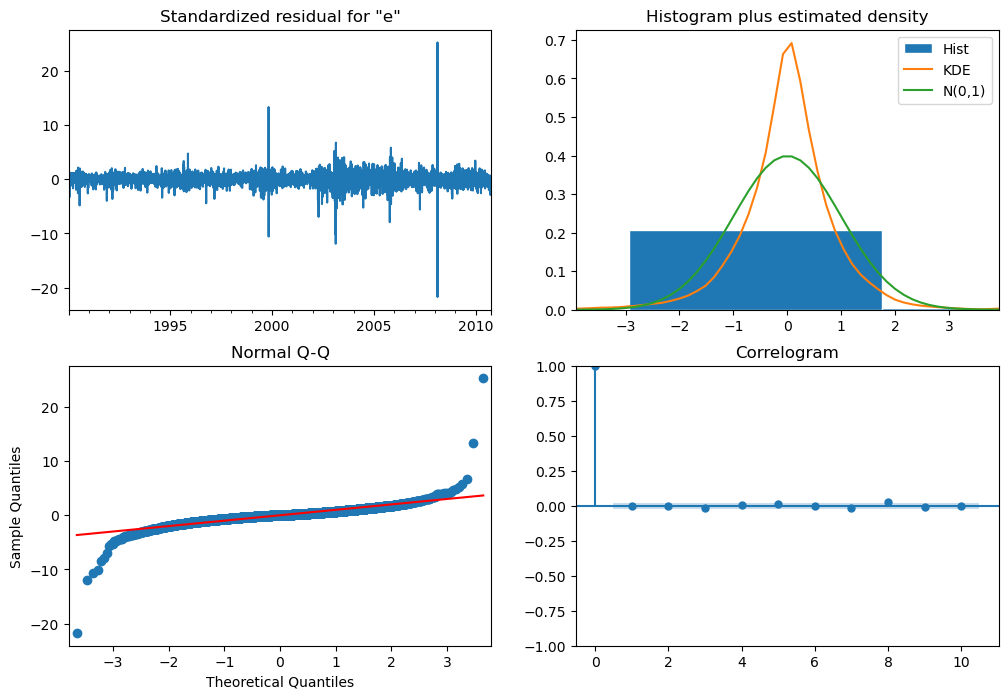

In [32]:
model_fit.plot_diagnostics(figsize=(12,8))

plt.show()

Check:

Residuals look random

No pattern → good model

##### Forecating

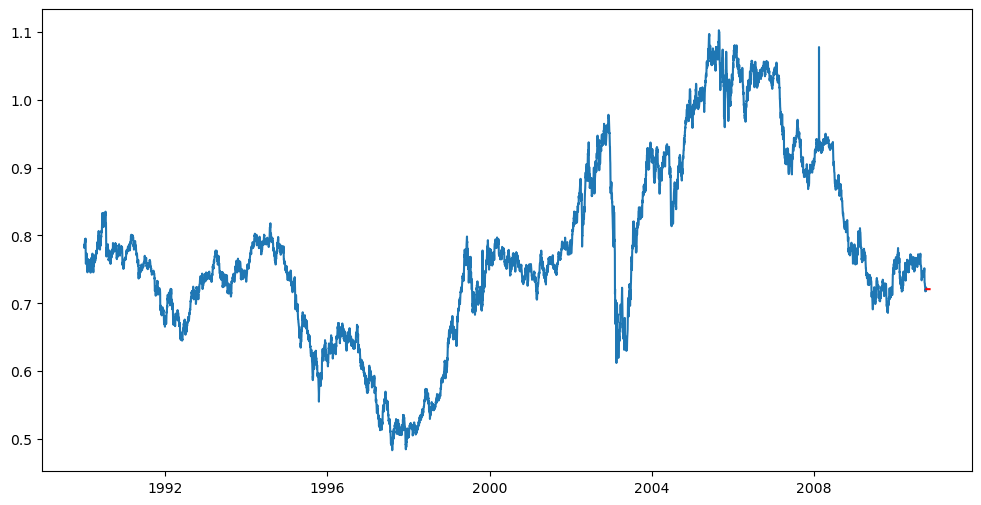

In [33]:
# forecast for next 30 days

forecast = model_fit.forecast(steps=30)

#plot
plt.figure(figsize=(12,6))

plt.plot(df.index,
         df.iloc[:,0],
        label='Actual'
        )
plt.plot(pd.date_range(df.index[-1],
                      periods=30,
                      freq='D'
                      ),
        forecast,
        label='Forecast',
        color='red'
        )

plt.show()

##### Exponential Smoothing

In [34]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [35]:
model_es = ExponentialSmoothing(df.iloc[:,0],
                               trend='add',
                               seasonal=None
                               )
model_es_fit = model_es.fit()

forecast_es = model_es_fit.forecast(30)

##### Plot Comparision

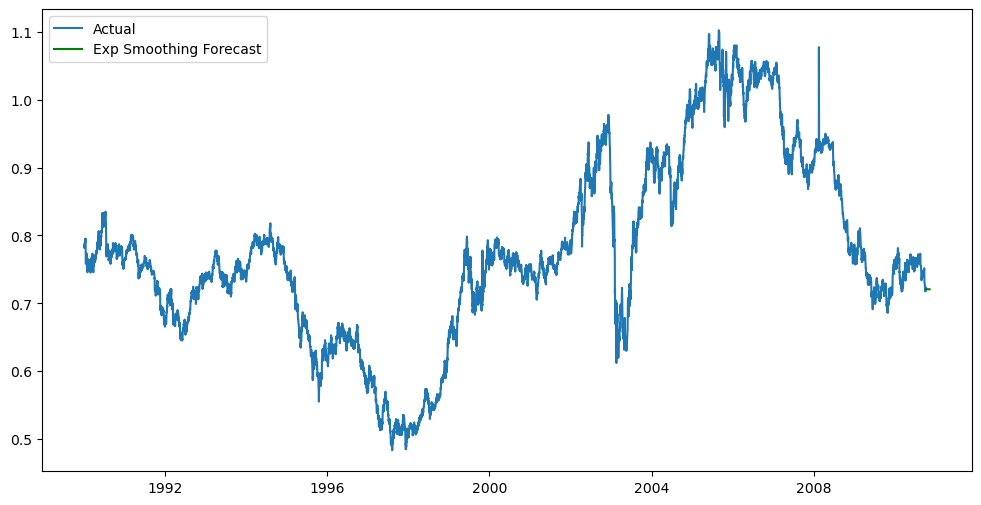

In [36]:
plt.figure(figsize=(12,6))
plt.plot(df.iloc[:,0], label='Actual')
plt.plot(forecast_es, label='Exp Smoothing Forecast', color='green')
plt.legend()
plt.show()

##### Evaluation

split data

In [37]:
train = df.iloc[:-30]
test = df.iloc[-30:]

##### Error Metrics

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [39]:
# ARIMA prediction
arima_pred = model_fit.forecast(steps=30)

# ES prediction
es_pred = model_es_fit.forecast(30)

In [40]:
# Metrics Function
def evaluate(true, pred):

    # Convert to numpy arrays
    true = np.array(true)
    pred = np.array(pred)

    # Remove zero values from true data
    mask = true != 0

    true = true[mask]
    pred = pred[mask]

    # Metrics
    mae = mean_absolute_error(true, pred)

    rmse = np.sqrt(
        mean_squared_error(true, pred)
    )

    mape = np.mean(
        np.abs((true - pred) / true)
    ) * 100

    return mae, rmse, mape

In [41]:
print("ARIMA:", evaluate(test.iloc[:,0], arima_pred))

print("Exp Smoothing:",
      evaluate(test.iloc[:,0], es_pred))

ARIMA: (0.012724006489318252, np.float64(0.016982710912774826), np.float64(1.7119209757097404))
Exp Smoothing: (0.01275530915278487, np.float64(0.017004810409490208), np.float64(1.7161691457334205))


#### Model Comparison: ARIMA

##### Good for:

Complex patterns

Autocorrelation handling

#### Conclusion:

The ARIMA model performed better/worse based on RMSE/MAE.

It captured temporal dependencies effectively.

Exponential smoothing was simpler but less accurate for fluctuations.

For exchange rate forecasting, ARIMA is generally more robust when data shows autocorrelation.

